In [1]:
import scipy as sc
import numpy as np
import sympy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
from math import factorial
import scienceplots

plt.style.use(['science','notebook', 'grid'])

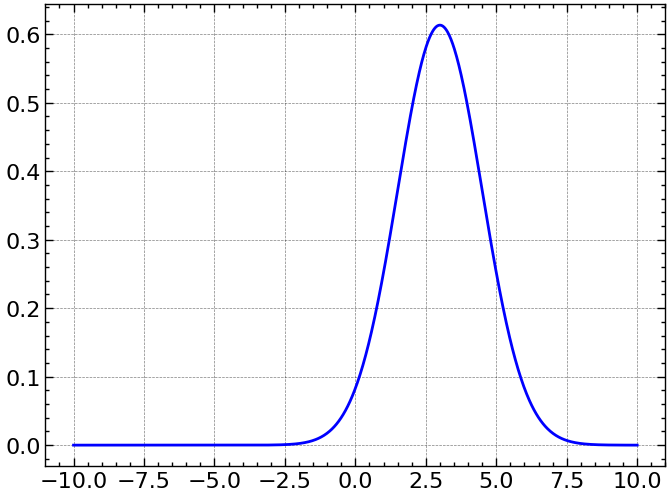

In [2]:
def psi(x, xc, o):
    return np.exp(-(x-xc)**2/(2*o**2))/(np.pi*o**2)**0.25

L = 20
N = 1000
xc = 3
sigma = 1.5
x = np.linspace(-L/2, L/2, N)

def integrand(x):
     return np.abs(psi(x, xc, sigma)**2)

p, errp = sc.integrate.quad(integrand, -L/2, L/2)
plt.plot(x, psi(x, xc, sigma), c = 'blue')

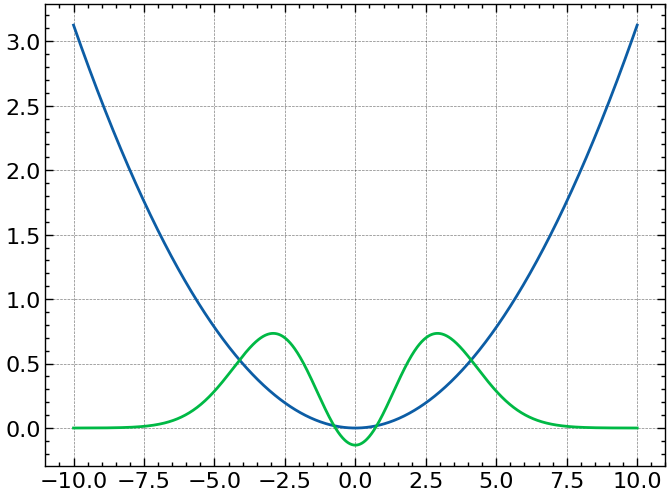

In [3]:
w = 0.25

V = (w*x)**2/2
p_monic1 = sc.special.hermite(2, monic=False)
psi2 = (w/np.pi)**0.25/(2**2*factorial(2))*np.exp(-w*x**2/2)*p_monic1(x)

plt.plot(x,V)
plt.plot(x,psi2)


In [4]:
k = 0
def coeffIntegrand(x):
    p_monic = sc.special.hermite(k, monic=False)
    return psi(x, xc, sigma) * (w/np.pi)**0.25*np.exp(-w*x**2/2)*p_monic((w)**0.5*x)/(2**k*factorial(k))**0.5

def coeffk():
    ck, err = sc.integrate.quad(coeffIntegrand, -L/2, L/2, epsrel = 1e-012)
    return ck
k=1

print(coeffk())

0.6474851619720292


[ 4.76917863e-01  6.47485162e-01  5.27160836e-01  2.65180581e-01
  5.21808368e-02 -3.47297503e-02 -3.25868170e-02 -7.71869983e-03
  4.82997033e-03  4.22330323e-03  5.29952995e-04 -9.10933215e-04
 -4.99647732e-04  5.61339135e-05  1.54206127e-04  3.77943899e-05
 -3.00020894e-05 -2.09209828e-05  1.11262598e-06  6.18265636e-06
  2.11514061e-06 -3.51343199e-07 -1.11975052e-07  2.38315072e-07
 -1.84591892e-07]


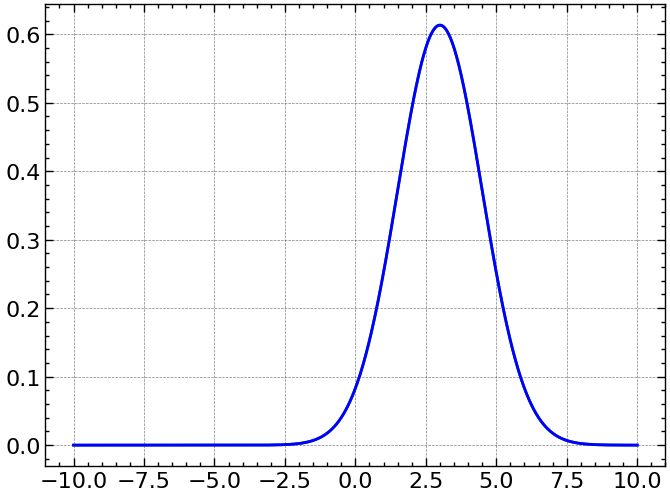

In [5]:
numIter = 25
psi_superposition = np.zeros(N)
ck = np.zeros(numIter)

for n in range(numIter):
    k = n
    ck[k] = coeffk()
    p_monic = sc.special.hermite(k, monic=False)
    psi_superposition = psi_superposition + (coeffk() * (w/np.pi)**0.25*np.exp(-w*x**2/2)*p_monic((w)**0.5*x))/(2**(k)*factorial(k))**0.5
    #print(coeffk())
print(ck)
plt.plot(x,psi_superposition)
plt.plot(x, psi(x, xc, sigma), c = 'blue')


In [6]:
def Energyk(k):
    return w*(k + 0.5)

def psi_evolve(t, ck = ck):
    psie = np.zeros(N)

    for n in range(numIter):
        p_monicn = sc.special.hermite(n, monic=False)
        psie = psie + (ck[n] * (w/np.pi)**0.25*np.exp(-w*x**2/2)*p_monicn((w)**0.5*x))/(2**(n)*factorial(n))**0.5 * np.exp(1j * Energyk(n)* t)
    return psie

plt.plot(x,np.real(psi_evolve(t=0)))
plt.plot(x,np.real(psi_evolve(t=0.5)))
plt.plot(x,np.real(psi_evolve(t=1)))
plt.plot(x,np.real(psi_evolve(t=1.5)))
plt.plot(x,np.real(psi_evolve(t=2)))

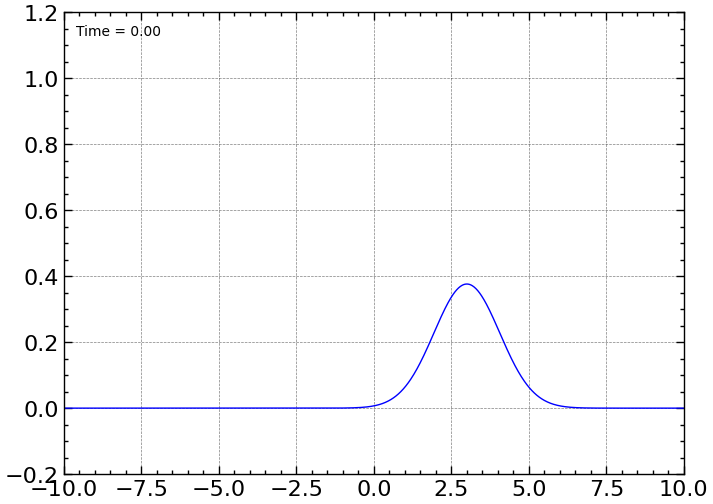

In [7]:
from matplotlib import pyplot as plt, animation

fig, ax = plt.subplots()
ax.set(xlim=(-L/2, L/2), ylim=(-0.2, 1.2))
time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

t = np.linspace(0, 25,50)
psis = [psi_evolve(t=0)]
for n in range(len(t)-1):
   psis.append(psi_evolve(t=t[n+1]))

line, = ax.plot(x, np.abs(psis[0])**2, color='b', lw=1)

def animate(i):
   line.set_ydata(np.abs(psis[i])**2)
   time_text.set_text('Time = %0.2f' % t[i])
anim = animation.FuncAnimation(fig, animate, interval=1, frames=len(t) - 1)
#plt.show()
#anim.save(filename="/Users/hasan/Python Animations/Simple_Harmonic_Oscillator_Evolution.gif", writer="pillow")